In [1]:
# Phase 1: Data Initialization & Resampling


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

%matplotlib inline
sns.set_style('whitegrid')
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Load and Prepare Time-Series Data
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-total-female-births.csv"
df = pd.read_csv(url)
df.columns = ['Date', 'Sales']
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df = df.asfreq('D')

print(f"Dataset Range: {df.index.min()} to {df.index.max()}")
print(f"Total Operational Days: {len(df)}")
df.head()

Dataset Range: 1959-01-01 00:00:00 to 1959-12-31 00:00:00
Total Operational Days: 365


,Sales
Date,
1959-01-01,35
1959-01-02,32
1959-01-03,30
1959-01-04,31
1959-01-05,44


In [5]:
# Phase 2: Trend & Seasonality Extraction

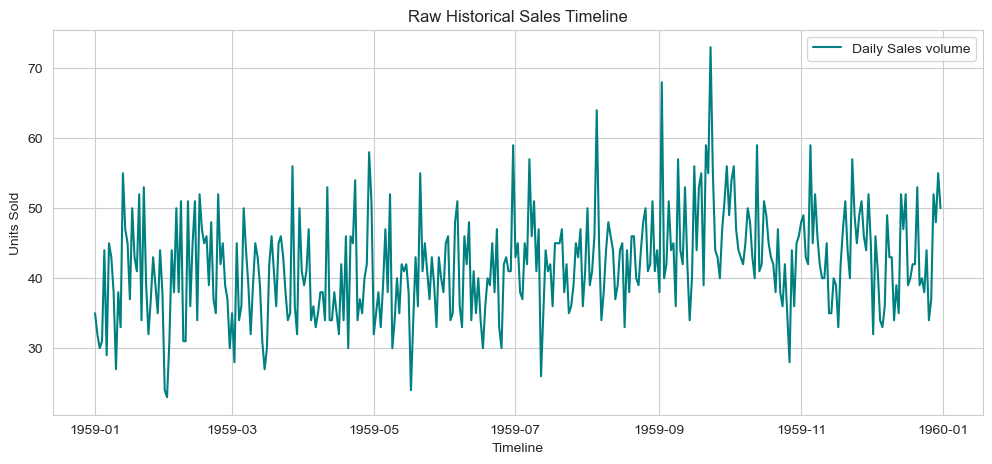

In [7]:
# Ploting the Baseline Sales Data
plt.figure(figsize=(12, 5))
plt.plot(df['Sales'], color='teal', label='Daily Sales volume')
plt.title('Raw Historical Sales Timeline')
plt.xlabel('Timeline')
plt.ylabel('Units Sold')
plt.legend()
plt.show()

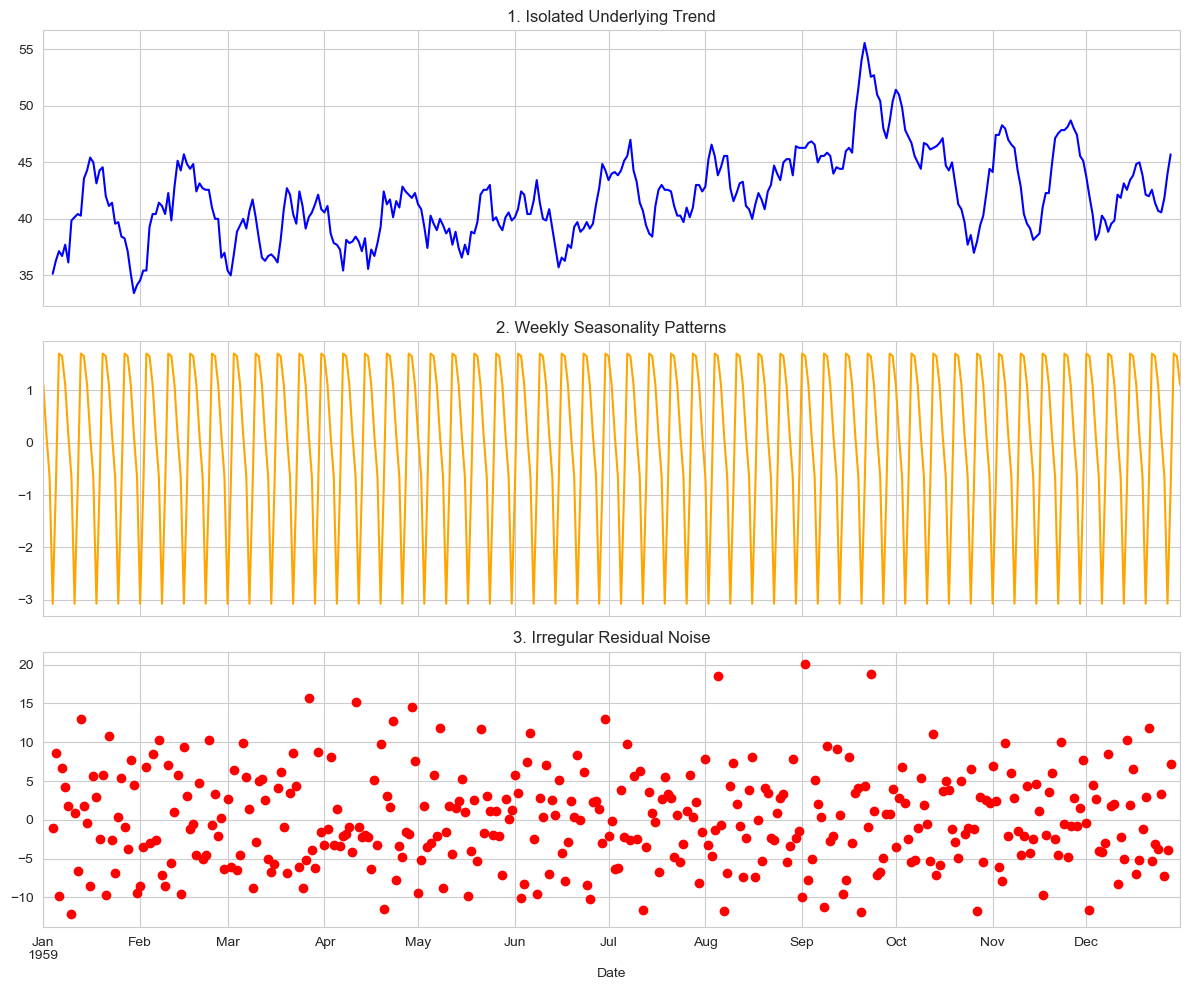

In [8]:
#Seasonal Decomposition
decomposition = seasonal_decompose(df['Sales'], model='additive', period=7)

# Plot components
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
decomposition.trend.plot(ax=ax1, color='blue', title='1. Isolated Underlying Trend')
decomposition.seasonal.plot(ax=ax2, color='orange', title='2. Weekly Seasonality Patterns')
decomposition.resid.plot(ax=ax3, color='red', linestyle='None', marker='o', title='3. Irregular Residual Noise')

plt.tight_layout()
plt.show()



In [9]:
#Phase 3: Train-Test Split 


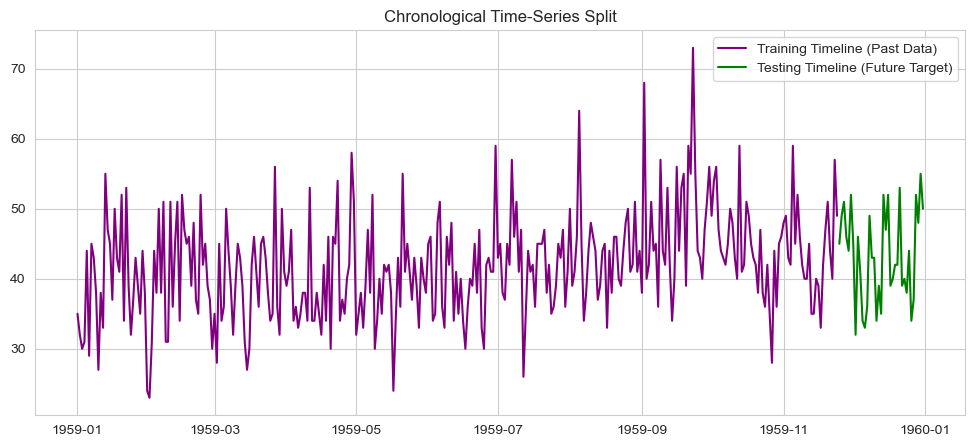

In [11]:
#Chronological Splitting
train_size = int(len(df) * 0.9)  
train, test = df.iloc[:train_size], df.iloc[train_size:]

plt.figure(figsize=(12, 5))
plt.plot(train.index, train['Sales'], label='Training Timeline (Past Data)', color='purple')
plt.plot(test.index, test['Sales'], label='Testing Timeline (Future Target)', color='green')
plt.title('Chronological Time-Series Split')
plt.legend()
plt.show()

In [12]:
# Phase 3: Time-Series Machine Learning Modeling


In [13]:
#Train the Holt-Winters Forecasting Model

hw_model = ExponentialSmoothing(train['Sales'], trend='add', seasonal='add', seasonal_periods=7)
fitted_model = hw_model.fit()

forecast_steps = len(test)
predictions = fitted_model.forecast(steps=forecast_steps)

predictions = pd.Series(predictions, index=test.index)
print("Forecasting Engine Training and Generation Complete!")


Forecasting Engine Training and Generation Complete!


In [14]:
# Phase 4: Model Evaluation


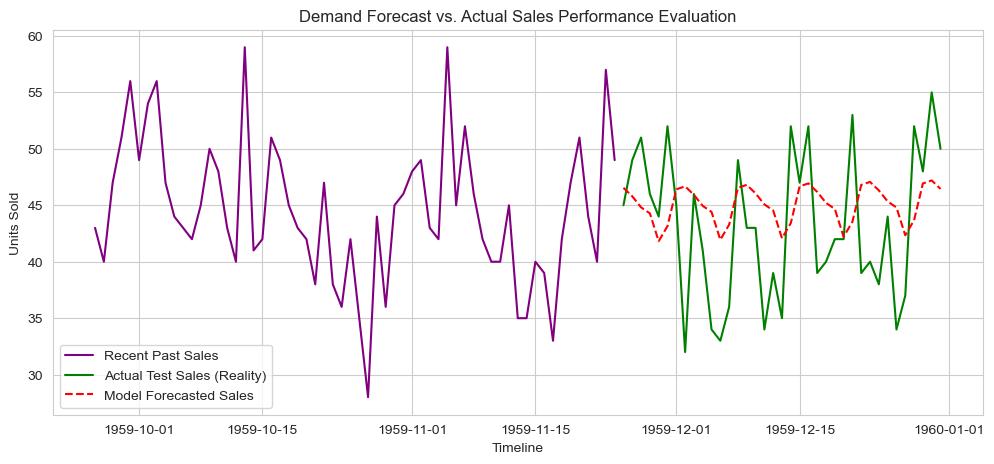

In [15]:
#Visualize Forecast vs. Reality
plt.figure(figsize=(12, 5))
plt.plot(train.index[-60:], train['Sales'][-60:], label='Recent Past Sales', color='purple')
plt.plot(test.index, test['Sales'], label='Actual Test Sales (Reality)', color='green')
plt.plot(predictions.index, predictions, label='Model Forecasted Sales', color='red', linestyle='--')
plt.title('Demand Forecast vs. Actual Sales Performance Evaluation')
plt.xlabel('Timeline')
plt.ylabel('Units Sold')
plt.legend()
plt.show()


In [16]:
#calculate Error Metrics
mae = mean_absolute_error(test['Sales'], predictions)
rmse = np.sqrt(mean_squared_error(test['Sales'], predictions))

print(f"--- Model Accuracy Summary ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} units")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} units")


--- Model Accuracy Summary ---
Mean Absolute Error (MAE): 5.50 units
Root Mean Squared Error (RMSE): 6.56 units


In [17]:
# Phase 5: Business Impact Analysis


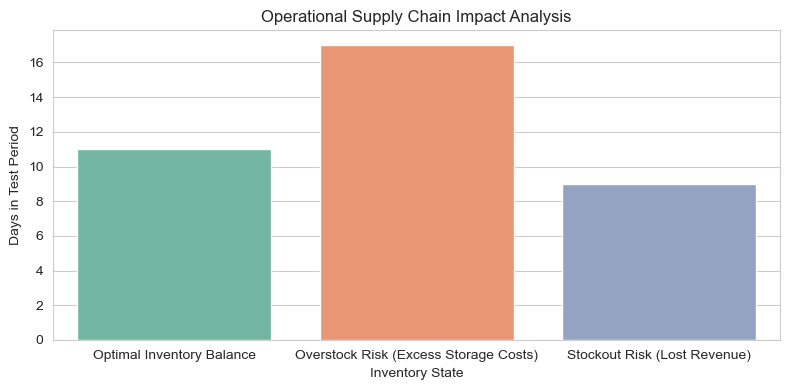


Operational Days Summary:
Inventory_Status
Overstock Risk (Excess Storage Costs)    17
Optimal Inventory Balance                11
Stockout Risk (Lost Revenue)              9
Name: count, dtype: int64


In [18]:
# Inventory Cost Simulation
business_df = pd.DataFrame({
    'Actual_Demand': test['Sales'],
    'Forecasted_Supply': predictions
}, index=test.index)

business_df['Variance'] = business_df['Forecasted_Supply'] - business_df['Actual_Demand']

# Define impact flags
def analyze_impact(val):
    if val < -3:
        return 'Stockout Risk (Lost Revenue)'
    elif val > 3: #
        return 'Overstock Risk (Excess Storage Costs)'
    else:
        return 'Optimal Inventory Balance'

business_df['Inventory_Status'] = business_df['Variance'].apply(analyze_impact)

plt.figure(figsize=(8, 4))
sns.countplot(data=business_df, x='Inventory_Status', palette='Set2', 
              order=['Optimal Inventory Balance', 'Overstock Risk (Excess Storage Costs)', 'Stockout Risk (Lost Revenue)'])
plt.title('Operational Supply Chain Impact Analysis')
plt.xlabel('Inventory State')
plt.ylabel('Days in Test Period')
plt.tight_layout()
plt.show()

print("\nOperational Days Summary:")
print(business_df['Inventory_Status'].value_counts())